# Análisis Estadístico del Cifrado

Este notebook complementa `encrypt.ipynb` y `decrypt.ipynb` con las métricas estadísticas estándar para evaluar la calidad del cifrado de imágenes:

1. **Histogramas de frecuencia** (original vs. cifrada)
2. **Correlación de píxeles adyacentes** (horizontal, vertical, diagonal) y sus coeficientes
3. **Varianza** (de intensidad de píxeles y del histograma)
4. **Entropía de Shannon**

La "imagen cifrada" que se usa aquí es la representación visual normalizada de 8 bits (página 0 del TIFF generado en `encrypt.ipynb`), ya que es la representación final de un solo byte por canal comparable directamente contra la imagen original la misma convención que ya usa `encrypt.ipynb` para mostrar el resultado.

In [42]:
%pip install numpy
%pip install pillow
%pip install matplotlib
%pip install tifffile

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tifffile

# Configuración de rutas (misma convención que encrypt.ipynb / decrypt.ipynb)
base = Path().resolve().parent
ruta_imagen = base / "Imagenes" / "Prueba1.jpg"

carpeta_resultados = base / "Resultados"
ruta_cifrado = carpeta_resultados / "Img Cifrada.tiff"

## Carga de imágenes

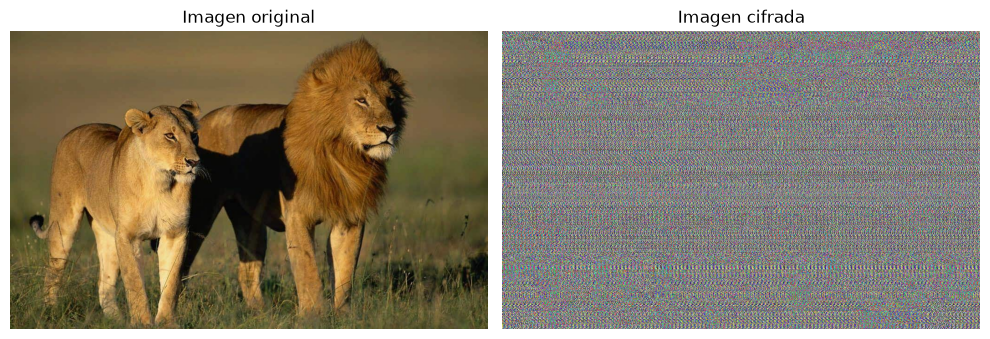

In [44]:
# Imagen original
img_original = Image.open(ruta_imagen).convert("RGB")
arr_original = np.array(img_original)
R_orig, G_orig, B_orig = arr_original[:, :, 0], arr_original[:, :, 1], arr_original[:, :, 2]

# Imagen cifrada: página 0 del TIFF (representación visual normalizada RGB de 8 bits)
img_cifrada_rgb = tifffile.imread(str(ruta_cifrado), key=0)
R_cif, G_cif, B_cif = img_cifrada_rgb[:, :, 0], img_cifrada_rgb[:, :, 1], img_cifrada_rgb[:, :, 2]

canales_originales = {"R": R_orig, "G": G_orig, "B": B_orig}
canales_cifrados = {"R": R_cif, "G": G_cif, "B": B_cif}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(arr_original)
axes[0].set_title("Imagen original")
axes[0].axis("off")
axes[1].imshow(img_cifrada_rgb)
axes[1].set_title("Imagen cifrada")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 1. Histogramas de frecuencia

Una imagen cifrada de buena calidad debe tener un histograma aproximadamente uniforme (plano) en cada canal, sin importar la forma del histograma original.

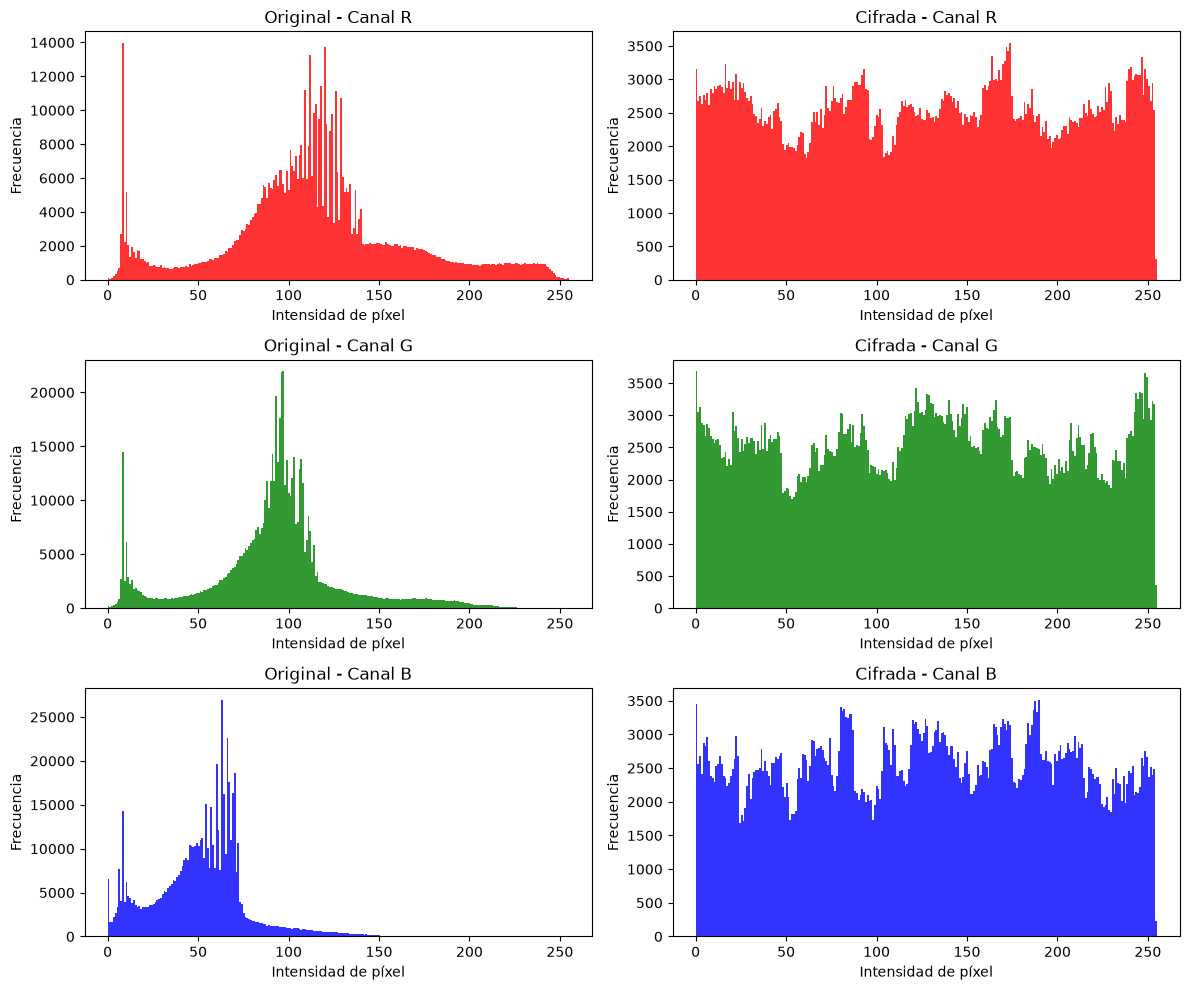

In [45]:
def graficar_histogramas(canales_orig, canales_cif):
    colores = {"R": "red", "G": "green", "B": "blue"}
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))

    for i, canal in enumerate(["R", "G", "B"]):
        axes[i, 0].hist(canales_orig[canal].ravel(), bins=256, range=(0, 255), color=colores[canal], alpha=0.8)
        axes[i, 0].set_title(f"Original - Canal {canal}")
        axes[i, 0].set_xlabel("Intensidad de píxel")
        axes[i, 0].set_ylabel("Frecuencia")

        axes[i, 1].hist(canales_cif[canal].ravel(), bins=256, range=(0, 255), color=colores[canal], alpha=0.8)
        axes[i, 1].set_title(f"Cifrada - Canal {canal}")
        axes[i, 1].set_xlabel("Intensidad de píxel")
        axes[i, 1].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

graficar_histogramas(canales_originales, canales_cifrados)

## 2. Correlación de píxeles adyacentes

Se toman pares de píxeles vecinos en tres direcciones (horizontal, vertical y diagonal), se grafican como nube de puntos y se calcula el coeficiente de correlación de Pearson:

$$r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

En la imagen original, los píxeles vecinos suelen estar muy correlacionados ($r \approx 1$). En una imagen bien cifrada, esa correlación debe romperse ($r \approx 0$).

In [46]:
def pares_adyacentes(canal, direccion, n_muestras=3000, semilla=42):
    h, w = canal.shape
    rng = np.random.default_rng(semilla)

    if direccion == "horizontal":
        filas = rng.integers(0, h, n_muestras)
        cols = rng.integers(0, w - 1, n_muestras)
        x, y = canal[filas, cols], canal[filas, cols + 1]
    elif direccion == "vertical":
        filas = rng.integers(0, h - 1, n_muestras)
        cols = rng.integers(0, w, n_muestras)
        x, y = canal[filas, cols], canal[filas + 1, cols]
    elif direccion == "diagonal":
        filas = rng.integers(0, h - 1, n_muestras)
        cols = rng.integers(0, w - 1, n_muestras)
        x, y = canal[filas, cols], canal[filas + 1, cols + 1]
    else:
        raise ValueError("direccion debe ser 'horizontal', 'vertical' o 'diagonal'")

    return x.astype(np.float64), y.astype(np.float64)


def coeficiente_correlacion(x, y):
    x_centrado = x - x.mean()
    y_centrado = y - y.mean()
    numerador = np.sum(x_centrado * y_centrado)
    denominador = np.sqrt(np.sum(x_centrado ** 2) * np.sum(y_centrado ** 2))
    return numerador / denominador if denominador != 0 else 0.0

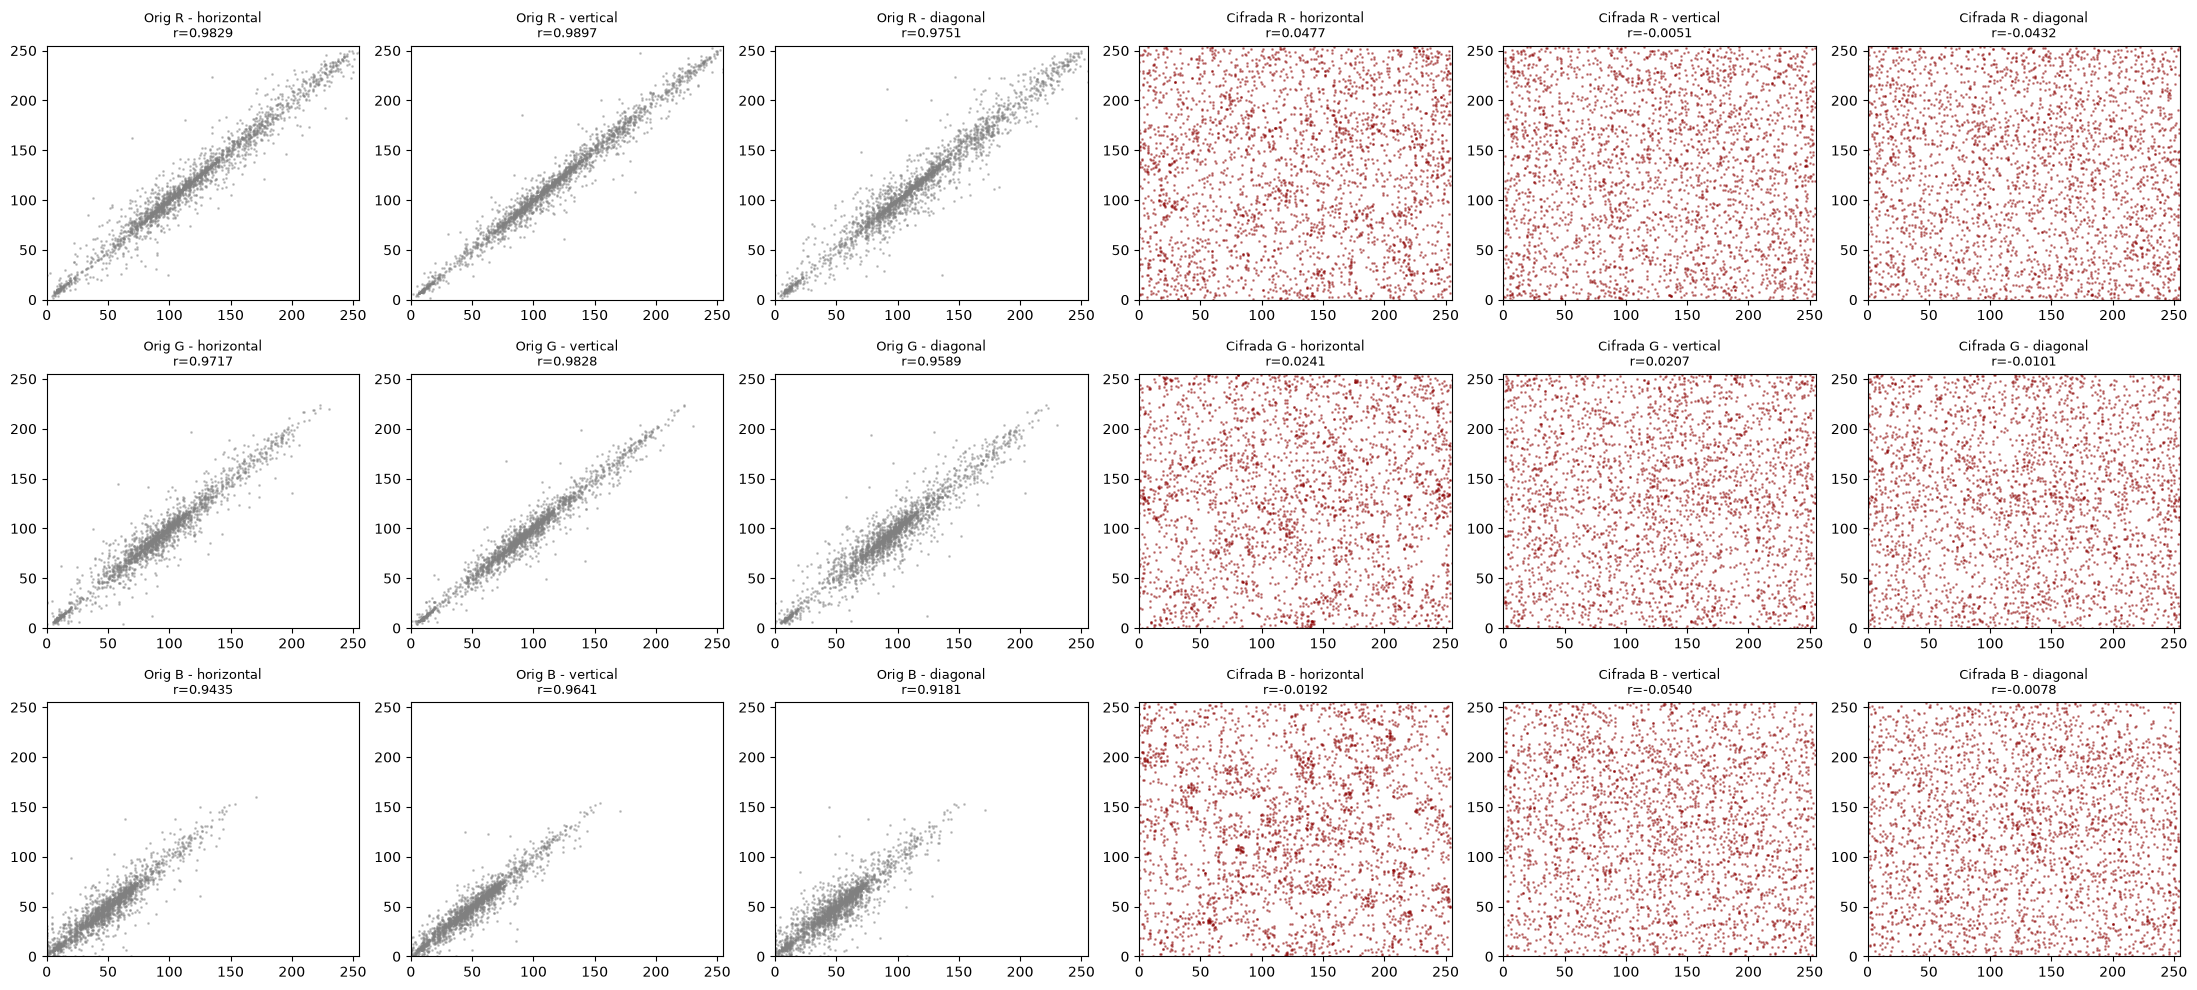

Canal   Dirección     r Original    r Cifrada     
R       horizontal    0.9829        0.0477        
R       vertical      0.9897        -0.0051       
R       diagonal      0.9751        -0.0432       
G       horizontal    0.9717        0.0241        
G       vertical      0.9828        0.0207        
G       diagonal      0.9589        -0.0101       
B       horizontal    0.9435        -0.0192       
B       vertical      0.9641        -0.0540       
B       diagonal      0.9181        -0.0078       


In [47]:
direcciones = ["horizontal", "vertical", "diagonal"]
resultados_correlacion = []

fig, axes = plt.subplots(3, 6, figsize=(22, 10))
for i, canal in enumerate(["R", "G", "B"]):
    for j, direccion in enumerate(direcciones):
        x_o, y_o = pares_adyacentes(canales_originales[canal], direccion)
        r_o = coeficiente_correlacion(x_o, y_o)
        axes[i, j].scatter(x_o, y_o, s=1, alpha=0.4, color="gray")
        axes[i, j].set_title(f"Orig {canal} - {direccion}\nr={r_o:.4f}", fontsize=9)
        axes[i, j].set_xlim(0, 255)
        axes[i, j].set_ylim(0, 255)

        x_c, y_c = pares_adyacentes(canales_cifrados[canal], direccion)
        r_c = coeficiente_correlacion(x_c, y_c)
        axes[i, j + 3].scatter(x_c, y_c, s=1, alpha=0.4, color="darkred")
        axes[i, j + 3].set_title(f"Cifrada {canal} - {direccion}\nr={r_c:.4f}", fontsize=9)
        axes[i, j + 3].set_xlim(0, 255)
        axes[i, j + 3].set_ylim(0, 255)

        resultados_correlacion.append({"canal": canal, "direccion": direccion, "r_original": r_o, "r_cifrada": r_c})

plt.tight_layout()
plt.show()

print(f"{'Canal':<8}{'Dirección':<14}{'r Original':<14}{'r Cifrada':<14}")
for res in resultados_correlacion:
    print(f"{res['canal']:<8}{res['direccion']:<14}{res['r_original']:<14.4f}{res['r_cifrada']:<14.4f}")

## 3. Varianza

Se calculan dos métricas de varianza:

- **Varianza de intensidad de píxeles**: dispersión simple de los valores de cada canal.
- **Varianza del histograma**: mide qué tan uniforme es la distribución de frecuencias entre los 256 niveles posibles. Un valor **menor** indica un histograma más plano (deseable en la imagen cifrada):

$$\mathrm{Var}(H) = \frac{1}{L^2} \sum_{i=0}^{L-1} \sum_{j=0}^{L-1} \frac{(h_i - h_j)^2}{2}$$

In [48]:
def varianza_histograma(canal):
    hist, _ = np.histogram(canal.ravel(), bins=256, range=(0, 255))
    hist = hist.astype(np.float64)
    diferencias = hist[:, None] - hist[None, :]
    return np.sum(diferencias ** 2) / (2 * len(hist) ** 2)


resultados_varianza = []
print(f"{'Canal':<8}{'Var. píxeles (orig)':<22}{'Var. píxeles (cif)':<22}{'Var. histograma (orig)':<24}{'Var. histograma (cif)':<24}")
for canal in ["R", "G", "B"]:
    var_pix_o = np.var(canales_originales[canal].astype(np.float64))
    var_pix_c = np.var(canales_cifrados[canal].astype(np.float64))
    var_hist_o = varianza_histograma(canales_originales[canal])
    var_hist_c = varianza_histograma(canales_cifrados[canal])
    resultados_varianza.append((canal, var_pix_o, var_pix_c, var_hist_o, var_hist_c))
    print(f"{canal:<8}{var_pix_o:<22.2f}{var_pix_c:<22.2f}{var_hist_o:<24.2f}{var_hist_c:<24.2f}")

Canal   Var. píxeles (orig)   Var. píxeles (cif)    Var. histograma (orig)  Var. histograma (cif)   
R       2518.03               5581.82               7149356.50              129999.79               
G       1429.14               5444.95               15320790.55             177578.90               
B       652.70                5221.75               19390618.64             169683.59               


## 4. Entropía de Shannon

$$H(m) = -\sum_{i=0}^{L-1} p(m_i) \log_2 p(m_i)$$

Para una imagen de 8 bits el máximo teórico es $H = 8$. Cuanto más cerca esté la entropía de la imagen cifrada de ese valor, más impredecible (aleatoria) es la distribución de sus píxeles.

In [49]:
def entropia_shannon(canal):
    hist, _ = np.histogram(canal.ravel(), bins=256, range=(0, 255))
    probabilidades = hist / hist.sum()
    probabilidades = probabilidades[probabilidades > 0]  # evitar log(0)
    return -np.sum(probabilidades * np.log2(probabilidades))


resultados_entropia = []
print(f"{'Canal':<8}{'Entropía original':<20}{'Entropía cifrada':<20}")
for canal in ["R", "G", "B"]:
    h_o = entropia_shannon(canales_originales[canal])
    h_c = entropia_shannon(canales_cifrados[canal])
    resultados_entropia.append((canal, h_o, h_c))
    print(f"{canal:<8}{h_o:<20.4f}{h_c:<20.4f}")

entropia_global_orig = entropia_shannon(arr_original)
entropia_global_cif = entropia_shannon(img_cifrada_rgb)
print(f"\nEntropía global original: {entropia_global_orig:.4f} (ideal: 8.0)")
print(f"Entropía global cifrada:  {entropia_global_cif:.4f} (ideal: 8.0)")

Canal   Entropía original   Entropía cifrada    
R       7.3907              7.9844              
G       6.8605              7.9792              
B       6.4333              7.9797              

Entropía global original: 7.3905 (ideal: 8.0)
Entropía global cifrada:  7.9875 (ideal: 8.0)


## Resumen

In [50]:
print("=" * 78)
print("RESUMEN DEL ANÁLISIS ESTADÍSTICO")
print("=" * 78)
print(f"\n{'Canal':<8}{'Entropía O':<13}{'Entropía C':<13}{'Var.Píx O':<14}{'Var.Píx C':<14}{'Var.Hist O':<14}{'Var.Hist C':<14}")
for i, canal in enumerate(["R", "G", "B"]):
    _, var_pix_o, var_pix_c, var_hist_o, var_hist_c = resultados_varianza[i]
    _, h_o, h_c = resultados_entropia[i]
    print(f"{canal:<8}{h_o:<13.4f}{h_c:<13.4f}{var_pix_o:<14.2f}{var_pix_c:<14.2f}{var_hist_o:<14.2f}{var_hist_c:<14.2f}")

print(f"\n{'Dirección':<14}{'r Original (prom.)':<20}{'r Cifrada (prom.)':<20}")
for direccion in direcciones:
    r_o_prom = np.mean([r["r_original"] for r in resultados_correlacion if r["direccion"] == direccion])
    r_c_prom = np.mean([r["r_cifrada"] for r in resultados_correlacion if r["direccion"] == direccion])
    print(f"{direccion:<14}{r_o_prom:<20.4f}{r_c_prom:<20.4f}")

RESUMEN DEL ANÁLISIS ESTADÍSTICO

Canal   Entropía O   Entropía C   Var.Píx O     Var.Píx C     Var.Hist O    Var.Hist C    
R       7.3907       7.9844       2518.03       5581.82       7149356.50    129999.79     
G       6.8605       7.9792       1429.14       5444.95       15320790.55   177578.90     
B       6.4333       7.9797       652.70        5221.75       19390618.64   169683.59     

Dirección     r Original (prom.)  r Cifrada (prom.)   
horizontal    0.9660              0.0175              
vertical      0.9789              -0.0128             
diagonal      0.9507              -0.0204             
